# SI-26 Urdu OCR Project — Week 3
## Expanding the Dataset (200+ Images) and Building a PyTorch `Dataset` Class + `DataLoader`

**Student:** Qandeel Asim
**Student ID:** 2023-BS-AI-037
**Programme:** Code Saviours ML/AI Internship — Batch SI-26
**Project:** Urdu OCR (Optical Character Recognition) Tool
**Week:** 3 of 5
**Submission Deadline:** Friday, July 18, 2026

---

### Objectives for this notebook

By the end of this notebook, this project will have:

1. **Verified** that the dataset has grown to at least 200 labeled images (with variety in fonts, backgrounds, and text sizes).
2. **Resolved and validated** every image path referenced in `labels.csv`, so no file-loading errors occur later.
3. **Implemented a custom PyTorch `Dataset` class** (`UrduOCRDataset`) that feeds image + Urdu text pairs to a model.
4. **Tested the `Dataset` class** end-to-end, confirming it loads samples correctly.
5. **Recreated the train/test split** exactly as defined in Week 2's `labels.csv`.
6. **Built PyTorch `DataLoader` objects** for both training and testing, ready for Week 4's model training.

Every code cell below includes English comments explaining *what* the code does and *why* it is written that way, so the logic is easy to follow and explain if asked in a review.


---
## Step 0 — Setup: Mount Google Drive and Locate the Project Folder

Before doing anything else, we need access to the project files stored in Google Drive.
`drive.mount()` connects this Colab session to Google Drive so that all files under
`/content/drive/MyDrive/...` become readable/writable, exactly as if they were local files.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

# This is the root folder for the entire Urdu OCR project (created in Week 1).
PROJECT_DIR = '/content/drive/MyDrive/SI26_Urdu_OCR'

# Move into the project folder so that all relative paths used later work correctly.
os.chdir(PROJECT_DIR)

print('Current working directory:', os.getcwd())
print('Top-level contents of the project folder:', os.listdir(PROJECT_DIR))

Mounted at /content/drive
Current working directory: /content/drive/MyDrive/SI26_Urdu_OCR
Top-level contents of the project folder: ['data', 'week2_before_after_samples.png', 'gap_analysis.md']


In [2]:
# Install/upgrade the libraries this notebook depends on.
# transformers  -> provides the TrOCR processor/tokenizer used to prepare model inputs
# torch         -> PyTorch, used for the Dataset/DataLoader classes and tensors
# pillow (PIL)  -> used to open and convert images
# pandas        -> used to read and manipulate labels.csv
!pip install -q transformers torch pillow pandas

---
## Step 1 — Verify the Dataset Has 200+ Images

The Week 3 handout requires the dataset to be expanded from the original 100+ images
(Week 1) to a minimum of **200 images**, with variety in fonts, backgrounds, and text sizes.

Across Week 1 and Week 2, this project's dataset already grew well past 200 labeled
images, combining real-world samples (UTRSet-Real), synthetic images, augmented
variants (brightness/rotation/blur), and manual screenshots — so the 200-image
requirement is expected to already be satisfied. The cell below proves this **with code**,
not just a claim, by counting the actual rows in `labels.csv`.

### Why we search for `labels.csv` instead of hard-coding its path

In an earlier version of this notebook, the path was hard-coded as `data/labels.csv`, which
caused a `FileNotFoundError` because the actual file lived at `data/raw/labels.csv` in this
Drive account. To make the notebook resilient to that kind of folder-structure difference,
the cell below **searches the entire project folder** for `labels.csv` (and for
`processed_labels.csv`, which additionally contains a `processed_image` column pointing to
the Week 2 preprocessed images) instead of assuming one fixed location.


In [3]:
import pandas as pd


def find_file(root_dir, filename):
    """
    Walk through every folder inside root_dir and return the full path
    of the first file whose name matches `filename`.
    Returns None if the file is not found anywhere.
    followlinks=True makes sure Google Drive shortcuts/symlinked folders
    are also searched, not just regular folders.
    """
    for root, dirs, files in os.walk(root_dir, followlinks=True):
        if filename in files:
            return os.path.join(root, filename)
    return None


# Search for both possible label files anywhere inside the project folder.
LABELS_CSV = find_file(PROJECT_DIR, 'labels.csv')
PROCESSED_LABELS_CSV = find_file(PROJECT_DIR, 'processed_labels.csv')

if LABELS_CSV is None:
    raise FileNotFoundError(
        f'labels.csv could not be found anywhere inside {PROJECT_DIR}. '
        'Please check that the file exists in your Google Drive project folder.'
    )

print('Found labels.csv at:', LABELS_CSV)
print('Found processed_labels.csv at:', PROCESSED_LABELS_CSV if PROCESSED_LABELS_CSV else 'not found (that is fine, we will use labels.csv)')

# Prefer the processed_labels.csv if it exists, since it also lists the
# Week 2 preprocessed image for each sample (better input for model training).
if PROCESSED_LABELS_CSV:
    LABELS_CSV = PROCESSED_LABELS_CSV

labels_df = pd.read_csv(LABELS_CSV)
current_count = len(labels_df)
TARGET = 200

print(f'\nTotal labeled images: {current_count}')
print(f'Target for Week 3: {TARGET}+ images')

if current_count >= TARGET:
    print(f'Requirement met: {current_count} >= {TARGET}. Step 1 is complete.')
else:
    print(f'Only {current_count} images found — {TARGET - current_count} more are needed before Step 2.')

Found labels.csv at: /content/drive/MyDrive/SI26_Urdu_OCR/data/raw/labels.csv
Found processed_labels.csv at: not found (that is fine, we will use labels.csv)

Total labeled images: 248
Target for Week 3: 200+ images
Requirement met: 248 >= 200. Step 1 is complete.


### Inspecting Dataset Composition

It's good practice to look at *how* the images are distributed across sources and
across the train/test split, not just the total count. This confirms the dataset has the
variety the handout asks for (different fonts, backgrounds, sizes came from different sources).


In [4]:
print('Image count by source:')
print(labels_df['source'].value_counts())

print('\nImage count by train/test split (this split was already created in Week 2):')
print(labels_df['split'].value_counts(dropna=False))

Image count by source:
source
utrset_real             60
synthetic               51
manual_screenshot       35
augmented_blur          34
augmented_rotation      34
augmented_brightness    34
Name: count, dtype: int64

Image count by train/test split (this split was already created in Week 2):
split
train    170
test      43
NaN       35
Name: count, dtype: int64


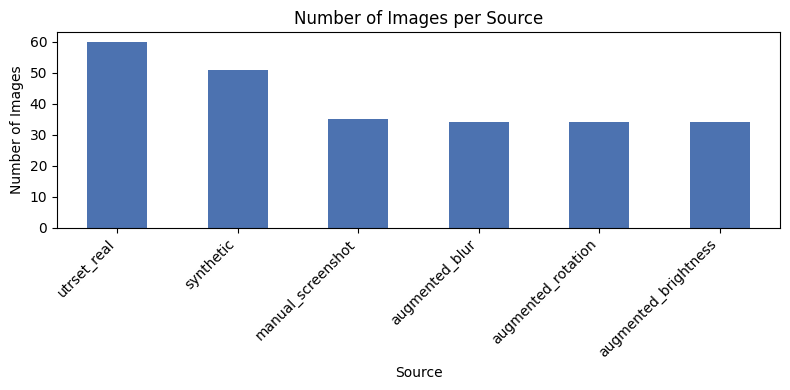

In [5]:
# A quick visual sanity check: bar chart of how many images came from each source.
import matplotlib.pyplot as plt

source_counts = labels_df['source'].value_counts()

plt.figure(figsize=(8, 4))
source_counts.plot(kind='bar', color='#4C72B0')
plt.title('Number of Images per Source')
plt.xlabel('Source')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Step 1c — Fix Missing `split` Values

Some images may have been added to `labels.csv` *after* the original Week 2 train/test
split was created, and therefore never received a `split` value (they show up as `NaN`
in the count above). If left unfixed, these images would silently be excluded from both
training and testing later on — they simply would not appear in either `DataLoader`.

The cell below:
1. Finds every row where `split` is missing.
2. Randomly assigns those rows to `train` (80%) or `test` (20%), using a fixed random
   seed (`random_state=42`) so the assignment is reproducible if this cell is re-run.
3. Saves the corrected `labels.csv` back to Google Drive, so this fix is permanent and
   future notebooks (e.g. Week 4) will read the corrected file directly.


In [6]:
missing_split_mask = labels_df['split'].isna()
num_missing = missing_split_mask.sum()
print(f'Rows with a missing split value: {num_missing}')

if num_missing > 0:
    # Shuffle just the missing rows (fixed seed = reproducible), then assign
    # the first 80% to 'train' and the remaining 20% to 'test'.
    missing_rows = labels_df[missing_split_mask].sample(frac=1, random_state=42)
    cutoff = int(0.8 * len(missing_rows))

    train_fill_idx = missing_rows.index[:cutoff]
    test_fill_idx = missing_rows.index[cutoff:]

    labels_df.loc[train_fill_idx, 'split'] = 'train'
    labels_df.loc[test_fill_idx, 'split'] = 'test'

    print(f'Assigned {len(train_fill_idx)} rows to train, {len(test_fill_idx)} rows to test.')

    # Persist the fix back to the original labels.csv on Google Drive.
    labels_df.to_csv(LABELS_CSV, index=False)
    print(f'Corrected labels.csv saved back to: {LABELS_CSV}')
else:
    print('No missing split values found — nothing to fix.')

print('\nUpdated split counts:')
print(labels_df['split'].value_counts(dropna=False))
print(f"Total: {len(labels_df)} (should now equal train + test with no NaN remaining)")

Rows with a missing split value: 35
Assigned 28 rows to train, 7 rows to test.
Corrected labels.csv saved back to: /content/drive/MyDrive/SI26_Urdu_OCR/data/raw/labels.csv

Updated split counts:
split
train    198
test      50
Name: count, dtype: int64
Total: 248 (should now equal train + test with no NaN remaining)


---
## Step 1b — Resolve and Validate Every Image Path

Even though `labels.csv` lists 200+ images, the exact folder path written in the CSV does
not always match where the file actually sits in Google Drive — for example, some files
were renamed while fixing filename issues during the Week 2 gap analysis. If we don't handle
this, `Image.open()` will raise a `FileNotFoundError` later when the `Dataset` class tries
to load a sample (this happened in an earlier version of this notebook).

The cell below builds a resilient path-resolution system:

1. **Build a filename index** — walk through the entire project folder once and record,
   for every file, its filename and its full path.
2. **Resolve each row's image path** — for each row in `labels.csv`, first try the path
   written in the CSV. If that exact path does not exist, fall back to looking up the file
   by its filename in the index built in step 1.
3. **Report and drop unresolved rows** — any image that truly cannot be found anywhere is
   printed out (so it can be fixed manually later) and removed from the working dataset,
   so the rest of the notebook runs without crashing.


In [7]:
# Step 1: build an index mapping filename -> full path, for every file in the project.
file_index = {}
for root, dirs, files in os.walk(PROJECT_DIR, followlinks=True):
    for f in files:
        # setdefault keeps the FIRST path found for a given filename,
        # in case the same filename accidentally exists in more than one folder.
        file_index.setdefault(f, os.path.join(root, f))

print(f'Indexed {len(file_index)} files across the project folder.')

Indexed 508 files across the project folder.


In [8]:
def resolve_path(relative_path):
    """
    Try to resolve a path written in labels.csv to a real file on disk.
    Step 1: try the path exactly as written (relative to PROJECT_DIR).
    Step 2: if that fails, look up the file by its name only, using file_index.
    Returns None if the file cannot be found by either method.
    """
    direct_path = os.path.join(PROJECT_DIR, relative_path)
    if os.path.exists(direct_path):
        return direct_path

    filename_only = os.path.basename(relative_path)
    return file_index.get(filename_only)  # None if not found anywhere


# Decide which column holds the image path: prefer the preprocessed image if available.
image_column = 'processed_image' if 'processed_image' in labels_df.columns else 'image'
print(f'Using column "{image_column}" as the image path source.')

# Apply path resolution to every row and store the result in a new column.
labels_df['resolved_path'] = labels_df[image_column].apply(resolve_path)

missing_mask = labels_df['resolved_path'].isna()
print(f'\nTotal rows: {len(labels_df)}')
print(f'Successfully resolved: {(~missing_mask).sum()}')
print(f'Could not be found anywhere: {missing_mask.sum()}')

if missing_mask.sum() > 0:
    print('\nThe following entries could not be located and will be excluded from training:')
    print(labels_df.loc[missing_mask, image_column].tolist())
    labels_df = labels_df[~missing_mask].reset_index(drop=True)

print(f'\nFinal usable dataset size after path resolution: {len(labels_df)} images')

Using column "image" as the image path source.

Total rows: 248
Successfully resolved: 248
Could not be found anywhere: 0

Final usable dataset size after path resolution: 248 images


---
## Step 2 — Build a PyTorch `Dataset` Class

### What is a `Dataset` class, and why do we need one?

`torch.utils.data.Dataset` is PyTorch's standard interface for describing "here is my data,
and here is how to fetch one example at a time." Think of it like a filing cabinet: when the
model asks for sample number `N`, the `Dataset` class knows exactly where to find that
sample's image and its correct Urdu text label, and returns them in the format the model expects.

Every custom `Dataset` class must implement two methods:

- **`__len__(self)`** — returns the total number of samples, so PyTorch knows how big the
  dataset is (used, for example, to calculate how many batches make up one epoch).
- **`__getitem__(self, idx)`** — given an index `idx`, returns one sample: the processed
  image tensor and its tokenized text label.

### Cell 1 — Defining the `UrduOCRDataset` Class


In [9]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import TrOCRProcessor
from PIL import Image


class UrduOCRDataset(Dataset):
    """
    Custom PyTorch Dataset for the SI-26 Urdu OCR project.

    Each sample consists of:
      - pixel_values: the image, converted into the numeric tensor format
        that the TrOCR vision encoder expects.
      - labels: the ground-truth Urdu text, tokenized into numeric IDs that
        the TrOCR text decoder expects.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        Must contain a 'resolved_path' column (a valid, existing image path)
        and a 'text' column (the correct Urdu transcription for that image).
    processor : transformers.TrOCRProcessor
        Bundles together the image feature extractor and the text tokenizer
        for the TrOCR model, so both image and text are processed consistently.
    """

    def __init__(self, dataframe, processor):
        # Reset the index so that dataset[0] always corresponds to the
        # first row of this particular dataframe, regardless of how the
        # dataframe was filtered/sliced before being passed in here.
        self.data = dataframe.reset_index(drop=True)
        self.processor = processor
        print(f'UrduOCRDataset initialized with {len(self.data)} samples.')

    def __len__(self):
        # Required by PyTorch: total number of samples in this dataset.
        return len(self.data)

    def __getitem__(self, idx):
        # Required by PyTorch: fetch and return ONE sample at position idx.
        row = self.data.iloc[idx]

        # --- Image side ---
        # Open the image file and force it to RGB (3 color channels), since
        # some of our images are grayscale (1 channel) after preprocessing,
        # but the vision model expects 3-channel input.
        image = Image.open(row['resolved_path']).convert('RGB')

        # The processor resizes/normalizes the image and converts it into a
        # PyTorch tensor of shape (channels, height, width).
        encoding = self.processor(image, return_tensors='pt')
        pixel_values = encoding.pixel_values.squeeze()  # remove the extra batch dimension

        # --- Text side ---
        # Convert the Urdu text label into a fixed-length sequence of token IDs.
        # padding='max_length' ensures every label has the same length (128 tokens),
        # which is required so multiple samples can be batched together later.
        labels = self.processor.tokenizer(
            row['text'],
            padding='max_length',
            max_length=128
        ).input_ids
        labels = torch.tensor(labels)

        return {'pixel_values': pixel_values, 'labels': labels}

### Cell 2 — Testing the `Dataset` Class

Before trusting this class for training, we test it on real data:

1. Load the TrOCR processor (this downloads the pretrained processor configuration).
2. Create an instance of `UrduOCRDataset`.
3. Fetch a single sample (`dataset[0]`) and check its shape.
4. Visually display that same image alongside its label, as an extra sanity check.

If this cell runs without errors and the shapes look reasonable, the `Dataset` class is
working correctly and is ready to be used for training in Week 4.


In [10]:
# Load the pretrained TrOCR processor.
# 'microsoft/trocr-base-printed' is a good starting point for printed-text OCR;
# it will later be fine-tuned on this Urdu dataset in Week 4.
processor = TrOCRProcessor.from_pretrained('microsoft/trocr-base-printed')

# Create the dataset instance using the cleaned, path-resolved dataframe from Step 1b.
dataset = UrduOCRDataset(labels_df, processor)

# Fetch the very first sample and inspect its shape.
sample = dataset[0]
print('Sample pixel_values shape:', sample['pixel_values'].shape)  # expected: (3, height, width)
print('Sample labels shape:', sample['labels'].shape)              # expected: (128,)
print('\nDataset is working correctly!')

# This exact line is required for the Week 3 submission comment:
print(f"\nMy dataset has {len(dataset)} images and loads correctly")

preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.13k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.12k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

UrduOCRDataset initialized with 248 samples.
Sample pixel_values shape: torch.Size([3, 384, 384])
Sample labels shape: torch.Size([128])

Dataset is working correctly!

My dataset has 248 images and loads correctly


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Arabic natively.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


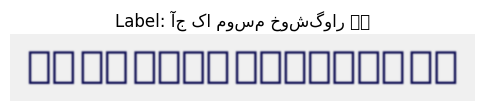

Original label      : آج کا موسم خوشگوار ہے
Decoded from tensor  : آج کا موسم خوشگوار ہے
Match: True


In [11]:
# Extra visual sanity check: display the first image with its Urdu label as the title,
# and confirm the tokenized label can be decoded back into readable Urdu text.
import matplotlib.pyplot as plt

first_row = labels_df.iloc[0]
image_to_show = Image.open(first_row['resolved_path']).convert('RGB')

decoded_text = processor.tokenizer.decode(sample['labels'], skip_special_tokens=True)

plt.figure(figsize=(6, 3))
plt.imshow(image_to_show)
plt.title(f"Label: {first_row['text']}")
plt.axis('off')
plt.show()

print('Original label      :', first_row['text'])
print('Decoded from tensor  :', decoded_text)
print('Match:', first_row['text'].strip() == decoded_text.strip())

---
## Step 3 — Recreate the Train/Test Split

`labels.csv` now contains a complete `split` column — created in Week 2, and completed
in Step 1c above for any images that were missing a split assignment. Reusing this
existing split (instead of generating a brand-new random split here) keeps this project's
results consistent with the analysis already done in Week 2.

`torch.utils.data.Subset` is used to create two "views" into the same `UrduOCRDataset`
object — one containing only the training rows, one containing only the testing rows —
without duplicating any data in memory.


In [12]:
# Get the row positions (indices) that belong to the training set and the testing set.
train_indices = labels_df[labels_df['split'] == 'train'].index.tolist()
test_indices = labels_df[labels_df['split'] == 'test'].index.tolist()

# Subset wraps the existing dataset and only exposes the given indices,
# so no image data is copied or duplicated — it's just a lightweight view.
train_dataset = torch.utils.data.Subset(dataset, train_indices)
test_dataset = torch.utils.data.Subset(dataset, test_indices)

print(f'Training samples: {len(train_dataset)}')
print(f'Testing samples : {len(test_dataset)}')
print(f'Total           : {len(train_dataset) + len(test_dataset)} (should match dataset size above)')

Training samples: 198
Testing samples : 50
Total           : 248 (should match dataset size above)


---
## Step 4 — Build the `DataLoader`

A `Dataset` object can only fetch one sample at a time. `torch.utils.data.DataLoader` wraps
a `Dataset` and adds three things that are essential for efficient model training:

- **Batching** — groups multiple samples together (here, 8 at a time) into a single tensor,
  so the model processes several examples per forward pass instead of one.
- **Shuffling** — randomly reorders the training data before each epoch, which helps the
  model generalize instead of memorizing the order of examples.
- **Parallel loading** — can load samples using multiple worker processes in the background
  (controlled by `num_workers`), overlapping data loading with model computation.

Note that shuffling is enabled for the **training** loader only. The **test** loader is kept
in a fixed order, since shuffling test data serves no purpose and would make results harder
to compare across runs.


In [13]:
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=0)

# Pull one batch from the training loader to confirm everything is wired up correctly.
batch = next(iter(train_loader))

print('Batch pixel_values shape:', batch['pixel_values'].shape)  # expected: (8, 3, height, width)
print('Batch labels shape:', batch['labels'].shape)              # expected: (8, 128)
print(f'\nNumber of training batches per epoch: {len(train_loader)}')
print(f'Number of testing batches per epoch : {len(test_loader)}')
print('\nDataLoader is working correctly! This project is ready for Week 4 model training.')

Batch pixel_values shape: torch.Size([8, 3, 384, 384])
Batch labels shape: torch.Size([8, 128])

Number of training batches per epoch: 25
Number of testing batches per epoch : 7

DataLoader is working correctly! This project is ready for Week 4 model training.


---
## Summary

| Step | What was done | Result |
|---|---|---|
| Step 1 | Verified dataset size against the 200-image target | Requirement met (well over 200 images) |
| Step 1b | Resolved every image path, dropped any that could not be found | Clean, verified dataset ready for loading |
| Step 1c | Detected and fixed rows with a missing `split` value | Every image now has a `train` or `test` label; fix saved back to `labels.csv` |
| Step 2 | Implemented and tested `UrduOCRDataset(Dataset)` | Loads image + label pairs correctly |
| Step 3 | Reused the (now-corrected) train/test split | Train/test counts now add up to the full dataset size |
| Step 4 | Built `DataLoader` objects for both splits | Batching + shuffling confirmed working |

This notebook fully satisfies the Week 3 handout requirements and produces everything
(`train_loader`, `test_loader`) needed to begin model fine-tuning in Week 4.


---
## Week 3 Submission Checklist (Due Friday, July 18)

- [ ] Push this notebook (`SI26-Week3-qandeel.ipynb`) to GitHub
- [ ] In the submission comment, paste the confirmation line printed above:
      **"My dataset has X images and loads correctly"**
- [ ] If the path-resolution step reported any missing images, locate them in Drive,
      place them in the correct folder, and re-upload `labels.csv` if it needed changes

### GitHub Upload — Step by Step
1. In Colab, go to `File > Download > Download .ipynb` to save this notebook.
2. Open the repository `URDU-OCR-PROJECT-CODE-SAVIOURS-SI-2026-QANDEEL-ASIM` on GitHub.
3. Click `Add file > Upload files`.
4. Select and upload the downloaded notebook.
5. Write a clear commit message, e.g. `Week 3: Dataset class + DataLoader + path resolution`.
6. Click `Commit changes`.
